<a href="https://colab.research.google.com/github/IvanVelezQu/Estructuras-base-de-datos/blob/main/Arboles/Arbol_Quadtree_Logistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import math
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

class Punto:
    def __init__(self, x, y, id_punto=None):
        self.x = x
        self.y = y
        self.id = id_punto #Sirve para referenciar un pedido (opcional)

    def distancia(self, otro):
        return math.sqrt((self.x - otro.x) ** 2 + (self.y - otro.y)**2)

class Rectangulo:
    def __init__(self, x, y, w, h):
        self.x = x #centro
        self.y = y #centro Y
        self.w = w #mitad del ancho
        self.h = h #mitad del alto

    def contiene(self, punto):
        return (punto.x >= self.x - self.w and punto.x <= self.x + self.w and
                punto.y >= self.y - self.h and punto.y <= self.y + self.h)

    def intersecta_circulo(self, circulo):
        closest_x = max(self.x - self.w, min(circulo.x, self.x + self.w))
        closest_y = max(self.y - self.h, min(circulo.y, self.y + self.h))
        dist_x = circulo.x - closest_x
        dist_y = circulo.y - closest_y
        return (dist_x**2 + dist_y**2) <= (circulo.r**2)

    def distancia_al_punto(self, punto):
        closest_x = max(self.x - self.w, min(punto.x, self.x + self.w))
        closest_y = max(self.y - self.h, min(punto.y, self.y + self.h))
        return math.sqrt((punto.x - closest_x)**2 + (punto.y - closest_y)**2)

class Circulo:
    def __init__(self, x, y, r):
        self.x = x
        self.y = y
        self.r = r

class QuadTree:
    def __init__(self, limite, capacidad):
        self.limite = limite        # Objeto Rectangulo
        self.capacidad = capacidad  # Max puntos por cuadrante
        self.puntos = []            # Puntos en este nodo
        self.dividido = False       # Estado de subdivision

    def subdividir(self):
        x = self.limite.x
        y = self.limite.y
        w = self.limite.w / 2
        h = self.limite.h / 2

        self.noroeste = QuadTree(Rectangulo(x - w, y + h, w, h), self.capacidad)
        self.noreste  = QuadTree(Rectangulo(x + w, y + h, w, h), self.capacidad)
        self.suroeste = QuadTree(Rectangulo(x - w, y - h, w, h), self.capacidad)
        self.sureste  = QuadTree(Rectangulo(x + w, y - h, w, h), self.capacidad)
        self.dividido = True

    def insertar(self, punto):
        if not self.limite.contiene(punto):
            return False

        if len(self.puntos) < self.capacidad:
            self.puntos.append(punto)
            return True
        else:
            if not self.dividido:
                self.subdividir()

            if self.noroeste.insertar(punto): return True
            if self.noreste.insertar(punto): return True
            if self.suroeste.insertar(punto): return True
            if self.sureste.insertar(punto): return True

    def buscar_radio(self, circulo, encontrados=None):
        if encontrados is None:
            encontrados = []

        if not self.limite.intersecta_circulo(circulo):
            return encontrados

        for p in self.puntos:
            if (p.x - circulo.x)**2 + (p.y - circulo.y)**2 <= circulo.r**2:
                encontrados.append(p)

        if self.dividido:
            self.noroeste.buscar_radio(circulo, encontrados)
            self.noreste.buscar_radio(circulo, encontrados)
            self.suroeste.buscar_radio(circulo, encontrados)
            self.sureste.buscar_radio(circulo, encontrados)

        return encontrados

    def vecino_mas_cercano(self, punto, mejor_dist=float('inf'), mejor_punto=None):
        if self.limite.distancia_al_punto(punto) > mejor_dist:
            return mejor_dist, mejor_punto

        for p in self.puntos:
            d = p.distancia(punto)
            if d < mejor_dist:
                mejor_dist = d
                mejor_punto = p

        if self.dividido:
            for hijo in [self.noroeste, self.noreste, self.suroeste, self.sureste]:
                mejor_dist, mejor_punto = hijo.vecino_mas_cercano(punto, mejor_dist, mejor_punto)

        return mejor_dist, mejor_punto

In [23]:
class LogisticaFuerzaBruta:
    def __init__(self, puntos):
        self.puntos = puntos

    def buscar_radio(self, x, y, r):
        encontrados = []
        r2 = r**2
        for p in self.puntos:
            if (p.x - x)**2 + (p.y - y)**2 <= r2:
                encontrados.append(p)
        return encontrados

    def vecino_mas_cercano(self, punto_query):
        mejor_dist = float('inf')
        mejor_punto = None
        for p in self.puntos:
            d = p.distancia(punto_query)
            if d < mejor_dist:
                mejor_dist = d
                mejor_punto = p
        return mejor_dist, mejor_punto

Generando 100000 puntos e insertando en QuadTree...

--- Búsqueda en Radio (500m) ---
Fuerza Bruta: Encontró 5 puntos en 0.057294 segundos.
QuadTree    : Encontró 5 puntos en 0.002545 segundos.

 Vecino Más Cercano 
Fuerza Bruta: Distancia 239.24m en 0.071978 segundos.
QuadTree    : Distancia 239.24m en 0.001615 segundos.


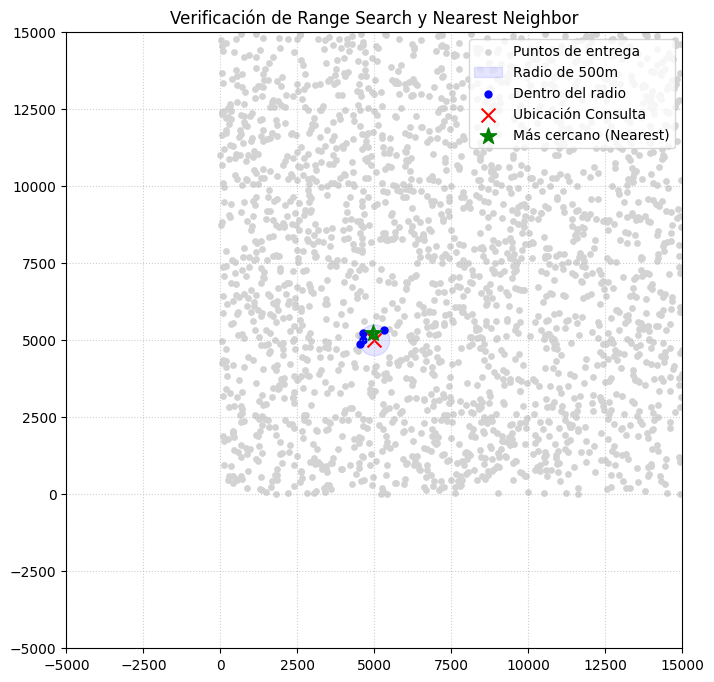

In [24]:
# --- 1. Generación de Datos ---
NUM_PUNTOS = 100000
AREA_SIZE = 100000 # 10km x 10km

# Límite principal para el QuadTree (Centro 5000,5000 y half-width/height de 5000)
limite_principal = Rectangulo(AREA_SIZE/2, AREA_SIZE/2, AREA_SIZE/2, AREA_SIZE/2)
qt = QuadTree(limite_principal, capacidad=10)
puntos_lista = []

print(f"Generando {NUM_PUNTOS} puntos e insertando en QuadTree...")
for i in range(NUM_PUNTOS):
    p = Punto(random.uniform(0, AREA_SIZE), random.uniform(0, AREA_SIZE), id_punto=i)
    puntos_lista.append(p)
    qt.insertar(p)

fb = LogisticaFuerzaBruta(puntos_lista)

# --- 2. Parámetros de Consulta ---
punto_consulta = Punto(5000, 5000) # Buscamos cerca del centro de la ciudad
RADIO = 500 # 500 metros
circulo_consulta = Circulo(punto_consulta.x, punto_consulta.y, RADIO)

# --- 3. Comparación ---
print("\n--- Búsqueda en Radio (500m) ---")
# Fuerza Bruta
start = time.perf_counter()
res_fb_radio = fb.buscar_radio(punto_consulta.x, punto_consulta.y, RADIO)
tiempo_fb_radio = time.perf_counter() - start

# QuadTree
start = time.perf_counter()
res_qt_radio = qt.buscar_radio(circulo_consulta)
tiempo_qt_radio = time.perf_counter() - start

print(f"Fuerza Bruta: Encontró {len(res_fb_radio)} puntos en {tiempo_fb_radio:.6f} segundos.")
print(f"QuadTree    : Encontró {len(res_qt_radio)} puntos en {tiempo_qt_radio:.6f} segundos.")

print("\n Vecino Más Cercano ")
# Fuerza Bruta
start = time.perf_counter()
dist_fb, cercano_fb = fb.vecino_mas_cercano(punto_consulta)
tiempo_fb_cercano = time.perf_counter() - start

# QuadTree
start = time.perf_counter()
dist_qt, cercano_qt = qt.vecino_mas_cercano(punto_consulta)
tiempo_qt_cercano = time.perf_counter() - start

print(f"Fuerza Bruta: Distancia {dist_fb:.2f}m en {tiempo_fb_cercano:.6f} segundos.")
print(f"QuadTree    : Distancia {dist_qt:.2f}m en {tiempo_qt_cercano:.6f} segundos.")

#  4. Verificación Visual
# Para que se pueda apreciar, graficaremos solo un "zoom" de la zona, no los 10,000 puntos a nivel macro.
zoom_rango = 10000
fig, ax = plt.subplots(figsize=(8, 8))

# Extraer puntos para plotear (solo los que entran en la ventana de zoom para agilizar render)
px_zoom, py_zoom = [], []
for p in puntos_lista:
    if abs(p.x - punto_consulta.x) < zoom_rango and abs(p.y - punto_consulta.y) < zoom_rango:
        px_zoom.append(p.x)
        py_zoom.append(p.y)

# 1. Plot de fondo (Puntos inactivos)
ax.scatter(px_zoom, py_zoom, c='lightgray', s=15, label='Puntos de entrega')

# 2. Plot del área circular de búsqueda
circle_patch = patches.Circle((punto_consulta.x, punto_consulta.y), RADIO,
                              color='Blue', alpha=0.1, label='Radio de 500m')
ax.add_patch(circle_patch)

# 3. Plot de puntos encontrados dentro del radio
if res_qt_radio:
    rx = [p.x for p in res_qt_radio]
    ry = [p.y for p in res_qt_radio]
    ax.scatter(rx, ry, c='blue', s=25, label='Dentro del radio')

# 4. Plot del origen y su vecino más cercano
ax.scatter(punto_consulta.x, punto_consulta.y, c='red', marker='x', s=100, label='Ubicación Consulta')
if cercano_qt:
    ax.scatter(cercano_qt.x, cercano_qt.y, c='green', marker='*', s=150, label='Más cercano (Nearest)')
    # Línea que los conecta
    ax.plot([punto_consulta.x, cercano_qt.x], [punto_consulta.y, cercano_qt.y], 'g--')

ax.set_xlim(punto_consulta.x - zoom_rango, punto_consulta.x + zoom_rango)
ax.set_ylim(punto_consulta.y - zoom_rango, punto_consulta.y + zoom_rango)
ax.set_aspect('equal', 'box')
ax.set_title("Verificación de Range Search y Nearest Neighbor")
ax.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

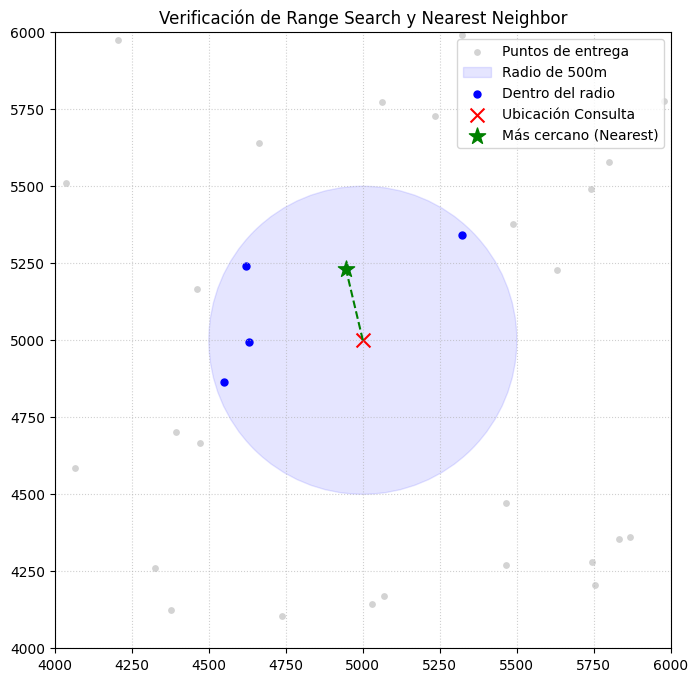

In [25]:
#  4. Verificación Visual con zoom
# Para que se pueda apreciar, graficaremos solo un "zoom" de la zona, no los 10,000 puntos a nivel macro.
zoom_rango = 1000
fig, ax = plt.subplots(figsize=(8, 8))

# Extraer puntos para plotear (solo los que entran en la ventana de zoom para agilizar render)
px_zoom, py_zoom = [], []
for p in puntos_lista:
    if abs(p.x - punto_consulta.x) < zoom_rango and abs(p.y - punto_consulta.y) < zoom_rango:
        px_zoom.append(p.x)
        py_zoom.append(p.y)

# 1. Plot de fondo (Puntos inactivos)
ax.scatter(px_zoom, py_zoom, c='lightgray', s=15, label='Puntos de entrega')

# 2. Plot del área circular de búsqueda
circle_patch = patches.Circle((punto_consulta.x, punto_consulta.y), RADIO,
                              color='blue', alpha=0.1, label='Radio de 500m')
ax.add_patch(circle_patch)

# 3. Plot de puntos encontrados dentro del radio
if res_qt_radio:
    rx = [p.x for p in res_qt_radio]
    ry = [p.y for p in res_qt_radio]
    ax.scatter(rx, ry, c='blue', s=25, label='Dentro del radio')

# 4. Plot del origen y su vecino más cercano
ax.scatter(punto_consulta.x, punto_consulta.y, c='red', marker='x', s=100, label='Ubicación Consulta')
if cercano_qt:
    ax.scatter(cercano_qt.x, cercano_qt.y, c='green', marker='*', s=150, label='Más cercano (Nearest)')
    # Línea que los conecta
    ax.plot([punto_consulta.x, cercano_qt.x], [punto_consulta.y, cercano_qt.y], 'g--')

ax.set_xlim(punto_consulta.x - zoom_rango, punto_consulta.x + zoom_rango)
ax.set_ylim(punto_consulta.y - zoom_rango, punto_consulta.y + zoom_rango)
ax.set_aspect('equal', 'box')
ax.set_title("Verificación de Range Search y Nearest Neighbor")
ax.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

#para que tamaño de datos el arbol-Quadtree comienza a ser mas rapido que "fuerza bruta"
#(no arboles, si listas, ...)?

El QuadTree comienza a ser más rápido que la fuerza bruta entre los 100 y 500 puntos.

#1. El "Overhead" (Costo de administración)

La fuerza bruta es mas rapida para conjunto de datos pequenos ya que la comparacion es mas rapida que la contruccion del arbol.

#2. Costo de Construcción vs. Costo de Consulta
La explicacion para la diferencia en rendimientos

Construir el QuadTree toma un tiempo de O(NlogN).

Buscar en fuerza bruta toma O(N).

Al ser datos estaticos el costo de generacion del arbol solo ocurre una vez, por lo que ya al tener todo precargado la busqueda se optimiza mucho. Si la ciudad cambiara cada x segundos en algunos casos de hasta 5000 puntos la fuerza bruta mostraria mejores resultados
